In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings


warnings.filterwarnings("ignore")

In [2]:
data = pd.read_csv("heart.csv")

Here, based off the given data, we train our ML model to predict whether a person will get heart disease or not

In [3]:
data.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


**Performing EDA on the given data**

In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 97.6 KB


In [5]:
data.describe() #note that we can only describe numeric data

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [6]:
data.isnull().sum() #no null values we see

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [7]:
data.duplicated().sum() #we see no duplicate data

np.int64(0)

<Axes: xlabel='HeartDisease'>

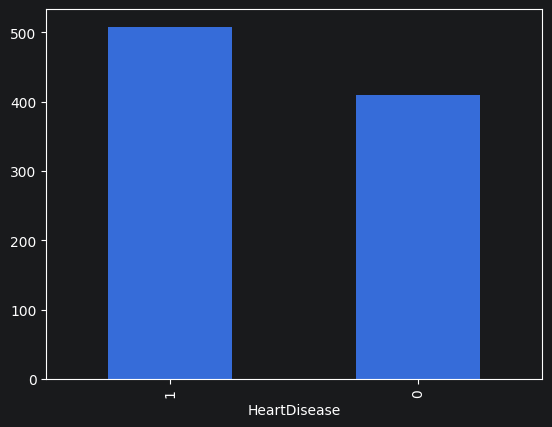

In [8]:
data['HeartDisease'].value_counts().plot(kind='bar') #bar plot of the value count of heart disease (1 stands for disease and 0 stands for no disease)

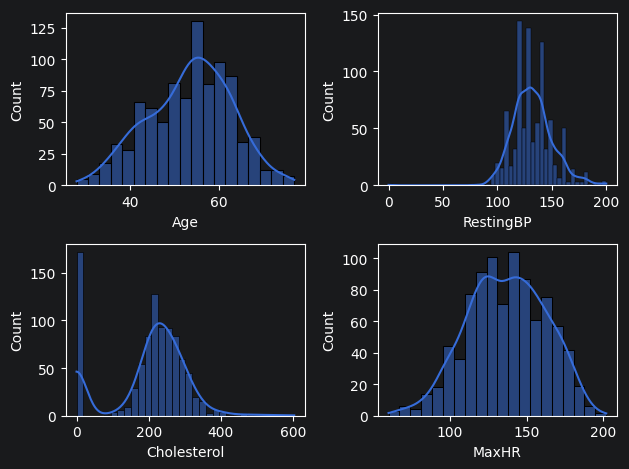

In [9]:
def plotting(var,num):
    plt.subplot(2,2,num) # .subplot divides the entire canvas into subsections of 2 x 2 , i.e, 2 rows and 2 columns and one section is selected by using the num parameter
    sns.histplot(data[var],kde=True)

plotting('Age', 1) #1 indicates that the first subplot is created where the histogram of age is plotted
plotting('RestingBP', 2)
plotting('Cholesterol', 3)
plotting('MaxHR', 4)
plt.tight_layout() #prevents overlapping


Cleaning the outliers

In [10]:
data['RestingBP'].value_counts() #we see 1 person has 0 resting bp

RestingBP
120    132
130    118
140    107
110     58
150     55
      ... 
174      1
117      1
192      1
129      1
164      1
Name: count, Length: 67, dtype: int64

In [11]:
data['Cholesterol'].value_counts() #we see 172 ppl have 0 cholesterol

Cholesterol
0      172
254     11
223     10
220     10
211      9
      ... 
353      1
278      1
157      1
176      1
131      1
Name: count, Length: 222, dtype: int64

 we fill out the empty spaces (0 data) with the mean of the rest of the data

In [12]:
"""  .loc[] accessor is used to filter and select specific data from your pandas DataFrame based on a condition.
    The structure of .loc is .loc[row_selection, column_selection].
'Cholesterol': This tells pandas to only look at the 'Cholesterol' column for those specific rows that passed the filter.  """


data['Cholesterol'] = data['Cholesterol'].replace(0, data['Cholesterol'].median())


In [13]:
data['Cholesterol'] = data['Cholesterol'].round(2)

In [14]:
resting_bp_mean = data.loc[data['RestingBP'] != 0, 'RestingBP'].mean()


In [15]:
data['RestingBP'] = data['RestingBP'].replace(0, resting_bp_mean)
data['RestingBP'] = data['RestingBP'].round(2)

In [16]:
print(data['Cholesterol'])

0      289
1      180
2      283
3      214
4      195
      ... 
913    264
914    193
915    131
916    236
917    175
Name: Cholesterol, Length: 918, dtype: int64


In [17]:
print(data['RestingBP'])

0      140.0
1      160.0
2      130.0
3      138.0
4      150.0
       ...  
913    110.0
914    144.0
915    130.0
916    130.0
917    138.0
Name: RestingBP, Length: 918, dtype: float64


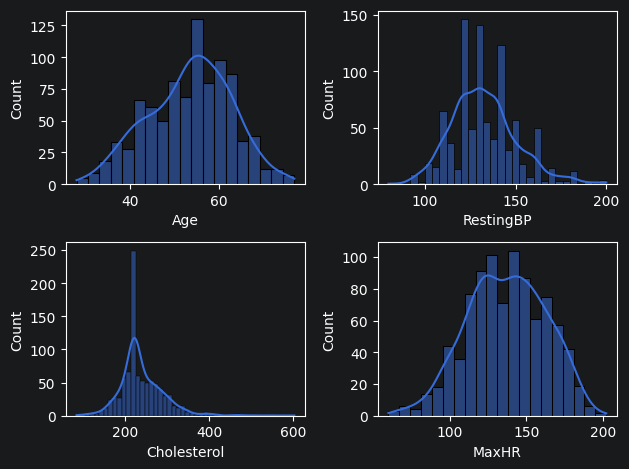

In [18]:
def plotting(var,num):
    plt.subplot(2,2,num) # .subplot divides the entire canvas into subsections of 2 x 2 , i.e, 2 rows and 2 columns and one section is selected by using the num parameter
    sns.histplot(data[var],kde=True)

plotting('Age', 1) #1 indicates that the first subplot is created where the histogram of age is plotted
plotting('RestingBP', 2)
plotting('Cholesterol', 3)
plotting('MaxHR', 4)
plt.tight_layout() #prevents overlapping

In [19]:
print((data['Cholesterol'] == 0).sum())
print((data['RestingBP'] == 0).sum())

0
0


comparing the categorical variables

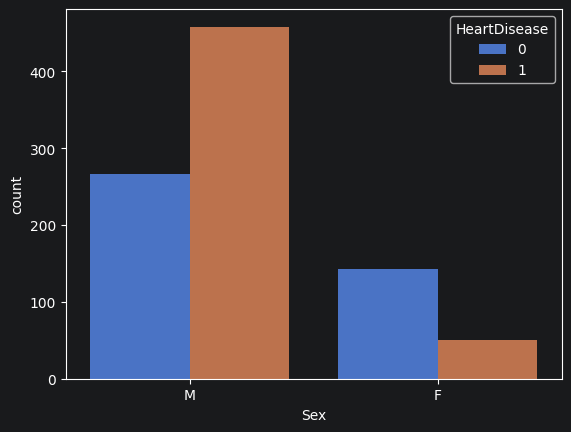

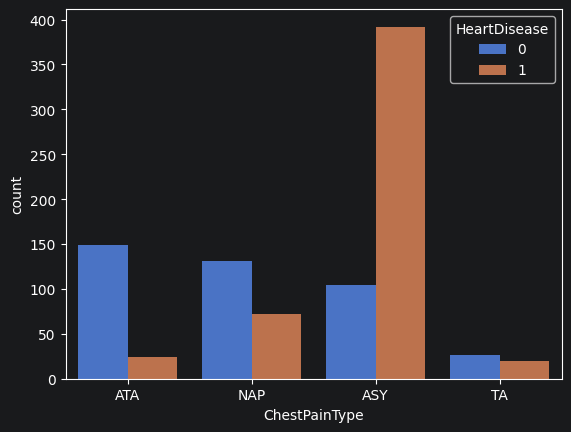

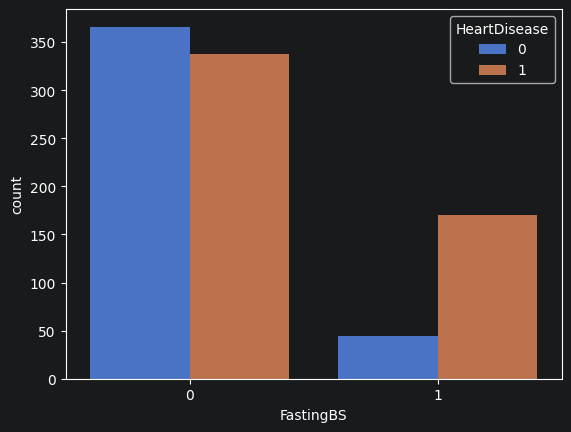

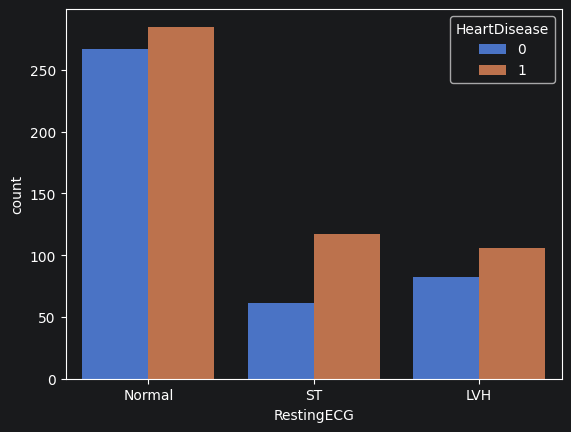

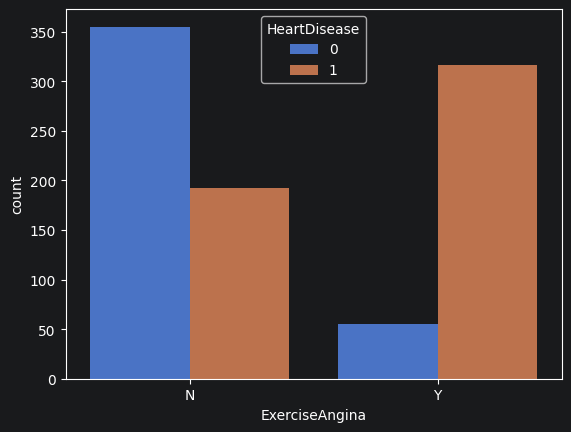

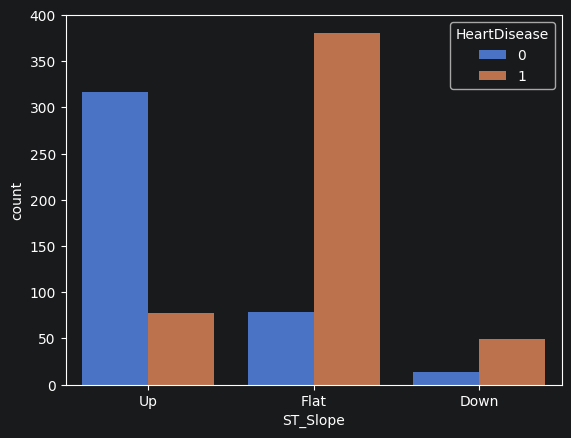

In [20]:
cat_cols = ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
for col in cat_cols:
    plt.figure() # This ensures each plot is created in its own figure
    sns.countplot(data= data, x= col, hue= data['HeartDisease']) #hue compares the 'col' with heart disease, the chances of heart disease is high for more orange level shown
    plt.show() # This explicitly displays each plot

Boxplots can compare numeric and categorical variable

<Axes: xlabel='HeartDisease', ylabel='Cholesterol'>

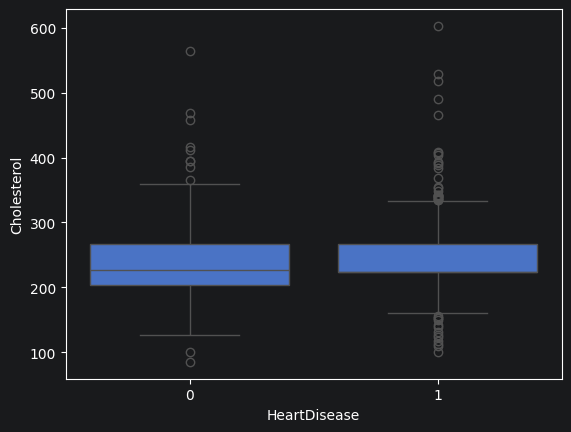

In [21]:
sns.boxplot(x=data['HeartDisease'], y= data['Cholesterol'])

<Axes: xlabel='HeartDisease', ylabel='Age'>

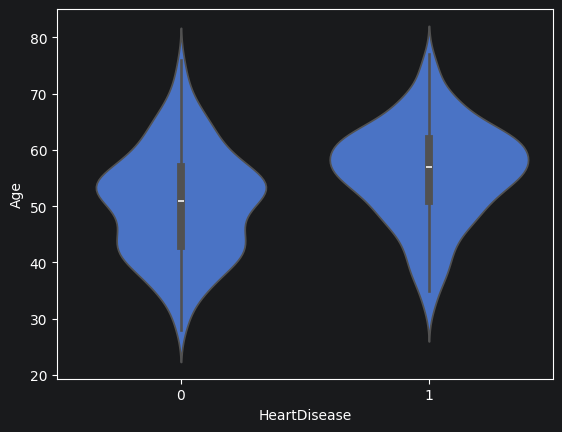

In [22]:
sns.violinplot(x=data['HeartDisease'], y= data['Age'] ) #violinplots are like boxplots only but it shows the distribution

<Axes: >

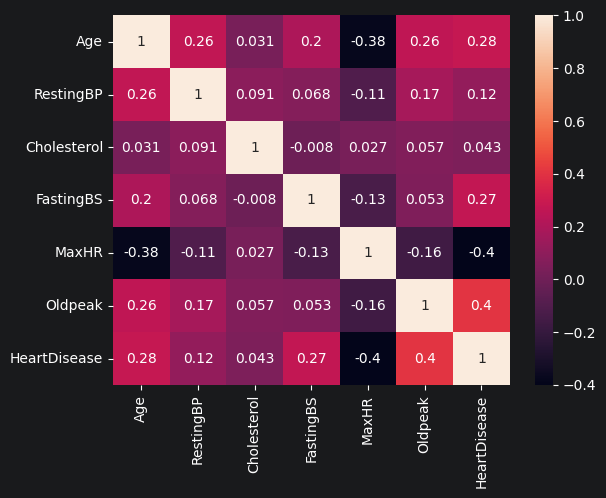

In [23]:
sns.heatmap(data.corr(numeric_only=True), annot=True) #correlation

Data preprocessing and cleaning

In [24]:
cleaned_data = pd.get_dummies(data,drop_first=True)
cleaned_data = cleaned_data.astype(int)
cleaned_data.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0,0,1,1,0,0,1,0,0,0,1
1,49,160,180,0,156,1,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0,0,1,1,0,0,0,1,0,0,1
3,48,138,214,0,108,1,1,0,0,0,0,1,0,1,1,0
4,54,150,195,0,122,0,0,1,0,1,0,1,0,0,0,1


Feature scaling

In [25]:
from sklearn.preprocessing import StandardScaler

numeric_Columns = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
scaler = StandardScaler()


cleaned_data.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0,0,1,1,0,0,1,0,0,0,1
1,49,160,180,0,156,1,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0,0,1,1,0,0,0,1,0,0,1
3,48,138,214,0,108,1,1,0,0,0,0,1,0,1,1,0
4,54,150,195,0,122,0,0,1,0,1,0,1,0,0,0,1


In [26]:
cleaned_data.columns

Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease', 'Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP',
       'ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST',
       'ExerciseAngina_Y', 'ST_Slope_Flat', 'ST_Slope_Up'],
      dtype='str')

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report,f1_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC


In [28]:
X = cleaned_data.drop('HeartDisease', axis=1)
y = cleaned_data['HeartDisease']

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [30]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [31]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "svm": SVC(kernel='rbf'),
    "knn": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB()
}

In [32]:
result = []

In [33]:
for name,model in models.items(): #.items returns the key, value pairs in a dictionary
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    result.append({
        "Model": name,
        "Accuracy": acc,
        "F1": f1,
    })

In [34]:
result

[{'Model': 'Logistic Regression',
  'Accuracy': 0.8641304347826086,
  'F1': 0.8792270531400966},
 {'Model': 'Decision Tree',
  'Accuracy': 0.7663043478260869,
  'F1': 0.7839195979899497},
 {'Model': 'svm', 'Accuracy': 0.842391304347826, 'F1': 0.861244019138756},
 {'Model': 'knn', 'Accuracy': 0.8641304347826086, 'F1': 0.8815165876777251},
 {'Model': 'Naive Bayes',
  'Accuracy': 0.8478260869565217,
  'F1': 0.8613861386138614}]

In [35]:
import joblib
joblib.dump(models["knn"], 'knn.pkl')
joblib.dump(scaler, "scaler.pkl")
joblib.dump(X.columns.tolist(), "columns.pkl")

['columns.pkl']

In [36]:
data.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140.0,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160.0,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130.0,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138.0,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150.0,195,0,Normal,122,N,0.0,Up,0


In [37]:
X.columns

Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA',
       'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_Y',
       'ST_Slope_Flat', 'ST_Slope_Up'],
      dtype='str')